Credit Risk Prediction

In [9]:
#Importing Libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

Load Dataset

In [10]:
path="loan_dataset_20000.csv"

df=pd.read_csv(path)
print(df.head(5))

   age  gender marital_status education_level  annual_income  monthly_income  \
0   59    Male        Married        Master's       24240.19         2020.02   
1   72  Female        Married      Bachelor's       20172.98         1681.08   
2   49  Female         Single     High School       26181.80         2181.82   
3   35  Female         Single     High School       11873.84          989.49   
4   63   Other         Single           Other       25326.44         2110.54   

  employment_status  debt_to_income_ratio  credit_score  loan_amount  ...  \
0          Employed                 0.074           743     17173.72  ...   
1          Employed                 0.219           531     22663.89  ...   
2          Employed                 0.234           779      3631.36  ...   
3          Employed                 0.264           809     14939.23  ...   
4          Employed                 0.260           663     16551.71  ...   

  loan_term  installment  grade_subgrade  num_of_open_ac

Dataset Understanding 

In [11]:
#Data Structure using shape and column function

print("Shape of dataset is: \n", df.shape)
print("\nColumns of dataset are: \n", df.columns)

#Dataset Info using info function info()
print("\nInfo of dataset is: \n", df.info())

#Dataset Summary 
print("\n Summary of dataset is: \n", df.describe())


Shape of dataset is: 
 (20000, 22)

Columns of dataset are: 
 Index(['age', 'gender', 'marital_status', 'education_level', 'annual_income',
       'monthly_income', 'employment_status', 'debt_to_income_ratio',
       'credit_score', 'loan_amount', 'loan_purpose', 'interest_rate',
       'loan_term', 'installment', 'grade_subgrade', 'num_of_open_accounts',
       'total_credit_limit', 'current_balance', 'delinquency_history',
       'public_records', 'num_of_delinquencies', 'loan_paid_back'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_in

Handling Missing Values

In [12]:
#Finding missing values
print(df.isnull().sum())

#There are No Missing Values in this dataset


age                     0
gender                  0
marital_status          0
education_level         0
annual_income           0
monthly_income          0
employment_status       0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
loan_purpose            0
interest_rate           0
loan_term               0
installment             0
grade_subgrade          0
num_of_open_accounts    0
total_credit_limit      0
current_balance         0
delinquency_history     0
public_records          0
num_of_delinquencies    0
loan_paid_back          0
dtype: int64


Data Visualization

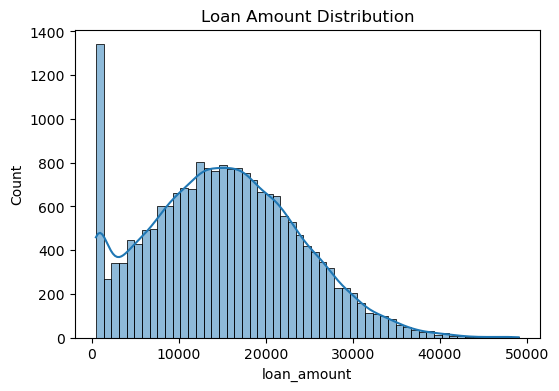

Income Distribution


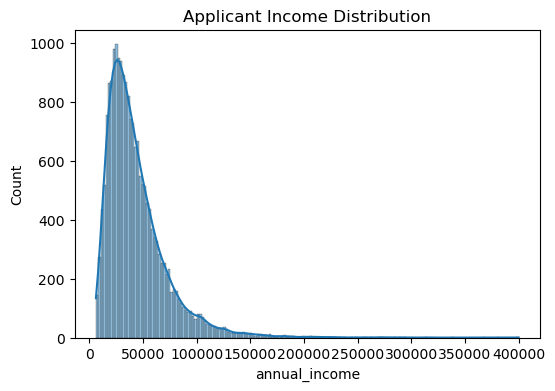



Education vs Loan Status


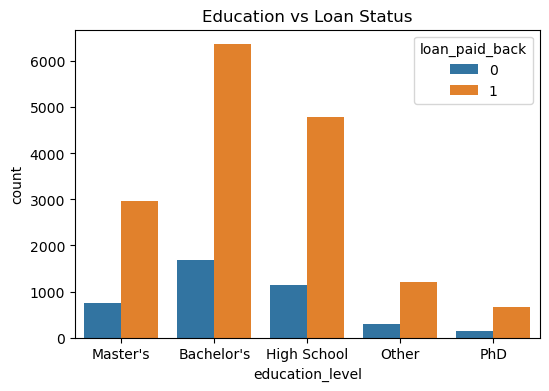

In [13]:
#Loan Amount Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["loan_amount"], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

#Income Distribution
print("Income Distribution")
plt.figure(figsize=(6,4))
sns.histplot(df["annual_income"], kde=True)
plt.title("Applicant Income Distribution")
plt.show()
print("\n")


#Education vs Loan Status
print("Education vs Loan Status")
plt.figure(figsize=(6,4))
sns.countplot(x='education_level', hue='loan_paid_back', data=df)
plt.title("Education vs Loan Status")
plt.show()

Convert Categorical Data

In [14]:
#Convert Convert Categorical Data Into Numerical

df = pd.get_dummies(df, drop_first=True) 

Split Data for Taraining and testing the model

In [15]:
# Features and target
X = df.drop('loan_paid_back', axis=1) 
y = df['loan_paid_back']  

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Training, Prediction and Evaluating the Model Using Logistic Regression

Accuracy: 0.8335


c:\Users\ADVANCE COMPUTERS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


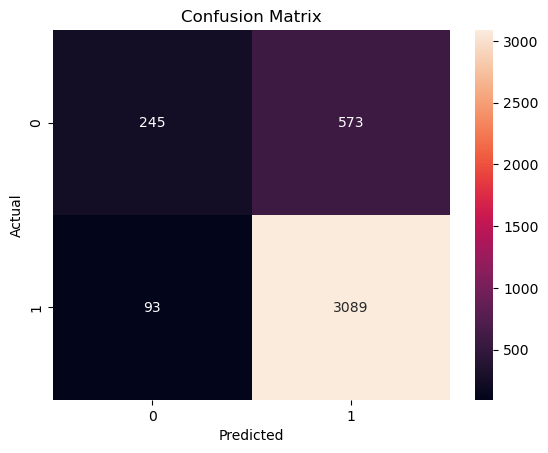

In [16]:
#Model Training

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Conclusion:

  Missing values successfully handled
  Data visualized using histograms and count plots
  Logistic Regression model trained
  Model evaluated using accuracy and confusion matrix
  Model predicts loan approval/denial reasonably well